# Exercise 6.2

Extend the 1-d FV solver for advection (Exercise 5.1 and 5.2) to solve the Inviscid Burgers equation,
$$
u_t + u u_x = 0
$$


You will need to change the Riemann solver and use the local velocity in the construction of the interface states.

Run examples with rarefaction IC,

$$
u(x,0) = 
\begin{cases}
1 & \quad 0 \le x < 0.5 \\
2 & \quad 0.5 \le x \le 1,
\end{cases}
$$

and sinusoidal initial data

$$
u(x,0) =
\begin{cases}
1 & \quad x < 1/3 \\
1 + \frac{1}{2} \sin(\frac{2 \pi (x - 1/3)}{1/3}) & \quad 1/3 \le x \le 2/3 \\
1 & \quad x > 2/3
\end{cases}
$$



In [9]:
import numpy as np
import matplotlib.pyplot as plt


In [10]:
#number of ghost cells for periodic BCs
nghost = 2

In [11]:
# Initial conditions
def rarefaction_IC(x):
    if 0<= x < 0.5:
        return 1.0
    else:
        return 2.0
    
def sine_IC(x):
    if x < 1/3:
        return 1.0
    elif x <= 2/3:
        return 1.0 + 0.5 * np.sin(2 * np.pi * (x-1/3) / (1/3))
    else:
        return 1.0

In [12]:
# Periodic BCs: fill ghost cells by copying from the opposite end of the array
def fill_ghost_periodic_bc(a):
    nx = len(a) - 2*nghost
    a[:nghost] = a[nx:nx+nghost] # left ghost cells
    a[nx+nghost:] = a[nghost:2*nghost] # right ghost cells
    return a


In [13]:
# Outflow BC: 

def fill_ghost_outflow_bc(a,nx):
    # left boundary
    a[0:nghost] = a[nghost]
    
    #right boundary
    a[nghost+nx-1+1:] = a[nghost+nx-1]

In [14]:
# Compute interface states using unlimited linear reconstruction
def compute_interface_states_unlimited(a, dx, dt):
    n = len(a)
    a_L = np.zeros_like(a)
    a_R = np.zeros_like(a)
    for i in range(nghost - 1, n - nghost + 1):
        a_L[i] = a[i] + (0.5 * dx) *(1 - dt/dx * a[i]) * (a[i+1] - a[i-1])/(2*dx)
        a_R[i] = a[i] - (0.5 * dx) *(1 + dt/dx * a[i]) * (a[i+1] - a[i-1])/(2*dx)
    return a_L, a_R

In [15]:
# Compute interface states using minmod slope limiter

def minmod(a, b):
    if np.abs(a) < np.abs(b) and (a * b > 0):
        return a
    elif np.abs(b) < np.abs(a) and (a * b > 0):
        return b
    else:
        return 0.0

def compute_interface_states_minmod(a, dx, dt):
    n = len(a)
    a_L = np.zeros_like(a)
    a_R = np.zeros_like(a)
    for i in range(nghost-1, n - nghost + 1):
        backward = (a[i] - a[i-1]) / dx   # (a[i] - a[i-1]) / dx
        forward  = (a[i+1] - a[i]) / dx  # (a[i+1] - a[i]) / dx
        slope = minmod(backward, forward)
        a_L[i] = a[i] + 0.5 * dx * (1 - dt/dx * a[i]) * slope
        a_R[i] = a[i] - 0.5 * dx * (1 + dt/dx * a[i]) * slope
    return a_L, a_R



In [ ]:
# Compute the MC limiter

def compute_interface_states_MC(a, dx, dt):
    n = len(a)
    a_L = np.zeros_like(a)
    a_R = np.zeros_like(a)

    for i in range(nghost - 1, n - nghost + 1):
        dc = 0.5 * (a[i+1] - a[i-1])   # centered difference
        dl = a[i+1] - a[i]              # forward difference
        dr = a[i] - a[i-1]              # backward difference

        # MC limiter (van Leer 1977, as in LeVeque 2002) -- zingales
        d1 = 2.0 * minmod(dl, dr)       
        d2 = minmod(dc, d1)             
        ldeltau = d2 if dl * dr > 0.0 else 0.0  # zero if signs differ (extremum)

        a_L[i] = a[i] + 0.5 * (1.0 - a[i]*dt/dx) * ldeltau
        a_R[i] = a[i] - 0.5 * (1.0 + a[i]*dt/dx) * ldeltau

    return a_L, a_R

In [17]:
# Riemann solver for burgers equation: if shock (ul > ur), compute shock speed
# and check whether the shock is moving to the left or the right, then use
# appropriate state. If there is no shock, then use simple upwinding based on the sign of the velocity u.
def Riemann(a_L, a_R):
    if a_L > a_R:  # shock
        s = 0.5 * (a_L + a_R)  # shock speed
        if s > 0:
            return a_L
        elif s < 0:
            return a_R
        else:
            return 0.0
    else:  # rarefaction
        if a_L >= 0:
            return a_L
        elif a_R <= 0:
            return a_R
        else:
            return 0.0


In [18]:
# Evolve the solution in time using the specified reconstruction method (unlimited or minmod)

def evolve(a_ghosted, nx, C, t_final, BC, unlimited, minmod, MC):
    dx = 1.0 / nx

    a = np.zeros(nx + 2*nghost)
    a[nghost:nghost+nx] = a_ghosted

    t = 0.0
    while t < t_final:
        
        if BC == 'periodic':
            # fill ghost cells for periodic BCs
            fill_ghost_periodic_bc(a)
        
        if BC == 'outflow':
            # fill ghost cells for outflow BaseException
            fill_ghost_outflow_bc(a,nx)
        
        # get the timestep based on the CFL condition, but also make sure we don't step past t_final
        dt = C * dx / np.max(np.abs(a[nghost:nghost+nx-1]))  # CFL condition based on max velocity in the domain
        dt = min(dt, t_final - t) # adjust final time step to hit t_final exactly
        
        #get the interface states using the specified reconstruction method
        if unlimited:
            a_L, a_R = compute_interface_states_unlimited(a, dx, dt)
        if minmod:
            a_L, a_R = compute_interface_states_minmod(a, dx, dt)
        if MC:
            a_L, a_R = compute_interface_states_MC(a, dx, dt)

        # do the update
        a_flux = np.zeros_like(a)
        F = np.zeros_like(a)
        for i in range(nghost-1, nghost+nx):
            a_flux[i] = Riemann(a_L[i], a_R[i+1])
            # burgers flux is F = 0.5 * a^2
            F[i] = 0.5 * a_flux[i]**2
        
        for i in range(nghost, nghost+nx):
            a[i] = a[i] - (dt/dx) * (F[i] - F[i-1])
        t += dt

    return a[nghost:nghost+nx]


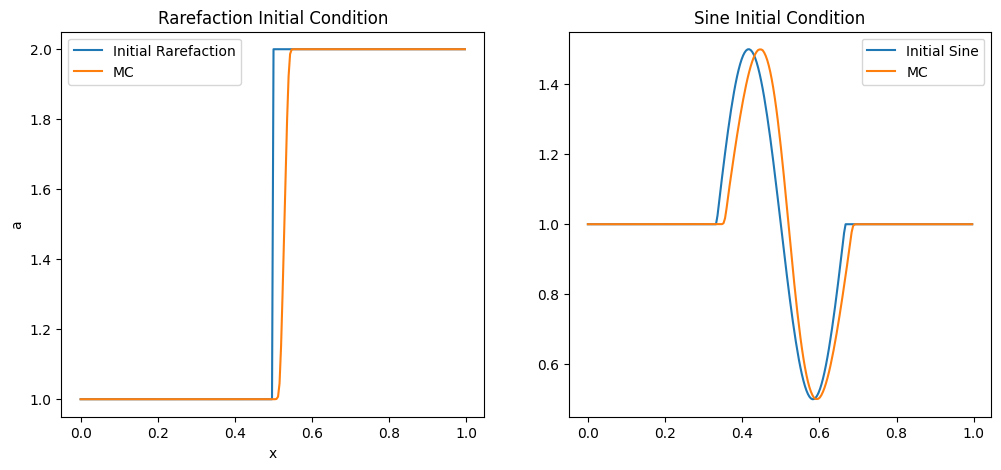

In [19]:
# Set parameters and run the simulation for both initial conditions and reconstruction methods

nx = 256
C = 0.8
x_initial = 0.0
x_final = 1.0
t_final = 0.02 # time to evolve until the wave has traveled across the domain once

X = np.linspace(0, 1, nx, endpoint=False)

a0_rarefaction = np.array([rarefaction_IC(x) for x in X])
a0_sine = np.array([sine_IC(x) for x in X])

a_rarefaction_minmod = evolve(a0_rarefaction.copy(), nx, C, t_final, BC='outflow', unlimited=False, minmod=True, MC=False)
a_sine_minmod = evolve(a0_sine.copy(), nx, C, t_final, BC='periodic', unlimited=False, minmod=True, MC=False)

a_rarefaction_unlimited = evolve(a0_rarefaction.copy(), nx, C, t_final, BC='outflow', unlimited=True, minmod=False, MC=False)
a_sine_unlimited = evolve(a0_sine.copy(), nx, C, t_final, BC='periodic', unlimited=True, minmod=False, MC=False)

a_rarefaction_MC = evolve(a0_rarefaction.copy(), nx, C, t_final, BC='outflow', unlimited=False, minmod=False, MC=True)
a_sine_MC = evolve(a0_sine.copy(), nx, C, t_final, BC='periodic', unlimited=False, minmod=False, MC=True)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(X, a0_rarefaction, label='Initial Rarefaction')
plt.plot(X, a_rarefaction_MC, label='MC')
plt.title(f'Rarefaction Initial Condition')
plt.xlabel('x')
plt.ylabel('a')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(X, a0_sine, label='Initial Sine')
plt.plot(X, a_sine_MC, label='MC')
plt.legend()
plt.title(f'Sine Initial Condition')


plt.show()

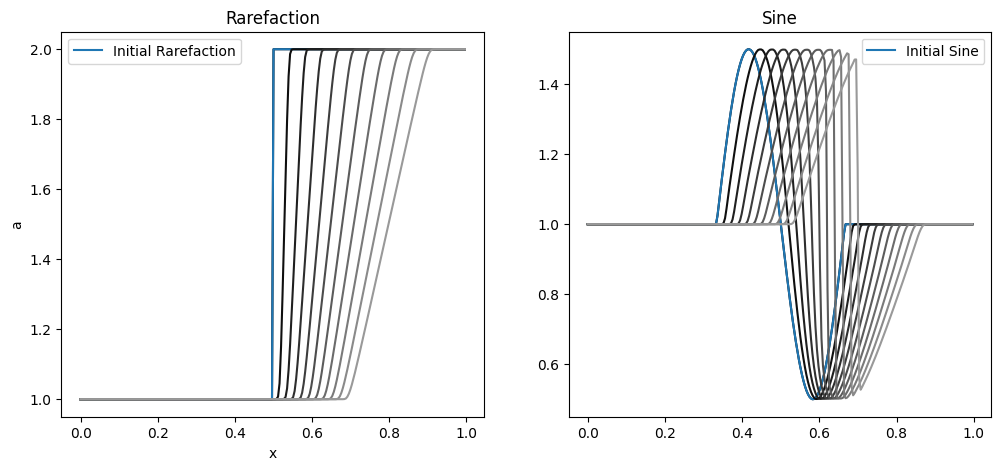

In [20]:
# plots like figs 6.4 and 6.5

nx = 256
C = 0.8
x_initial = 0.0
x_final = 1.0
X = np.linspace(0, 1, nx, endpoint=False)

a0_rarefaction = np.array([rarefaction_IC(x) for x in X])
a0_sine = np.array([sine_IC(x) for x in X])

t_final = np.linspace(0,0.2,11)

plt.figure(figsize=(12, 5))
for t in t_final:
    a_rarefaction_MC = evolve(a0_rarefaction.copy(), nx, C, t, BC='outflow', unlimited=False, minmod=False, MC=True)
    a_sine_MC = evolve(a0_sine.copy(), nx, C, t, BC='periodic', unlimited=False, minmod=False, MC=True)
    gray = t*30 / (len(t_final)-1)
    plt.subplot(1, 2, 1)
    plt.plot(X, a_rarefaction_MC, color =(gray,gray,gray))
    if t == 0.0:
        plt.plot(X, a0_rarefaction, label='Initial Rarefaction')
        plt.title(f'Rarefaction')
        plt.xlabel('x')
        plt.ylabel('a')
        plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(X, a_sine_MC, color =(gray,gray,gray))
    if t ==0.0:
        plt.plot(X, a0_sine, label='Initial Sine')
        plt.legend()
    plt.title(f'Sine')


plt.show()